In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("LoanApprovalPrediction.csv")
print("Hello")

In [2]:
 data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [12]:
obj = (data.dtypes == 'object')
print(list(obj[obj].index))

['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [9]:
data.drop('Loan_ID',axis=1,inplace=True)

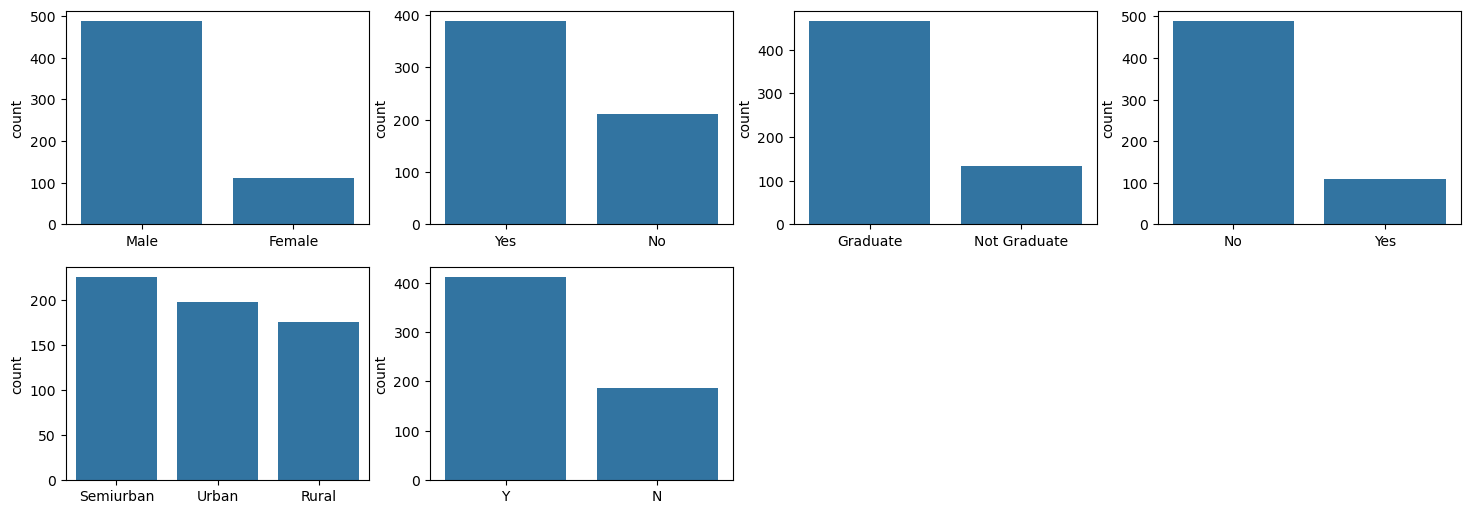

In [14]:
obj_cols = list(obj[obj].index)
plt.figure(figsize=(18,36))
index = 1

for col in obj_cols:
    y = data[col].value_counts()
    plt.subplot(11,4,index)
    sns.barplot(x=list(y.index),y=y)
    index += 1

In [19]:
from sklearn import preprocessing
obj = (data.dtypes == 'object')
le = preprocessing.LabelEncoder()
for col in list(obj[obj].index):
    data[col] = le.fit_transform(data[col])

print(len(list(obj[obj].index)))

0


<Axes: >

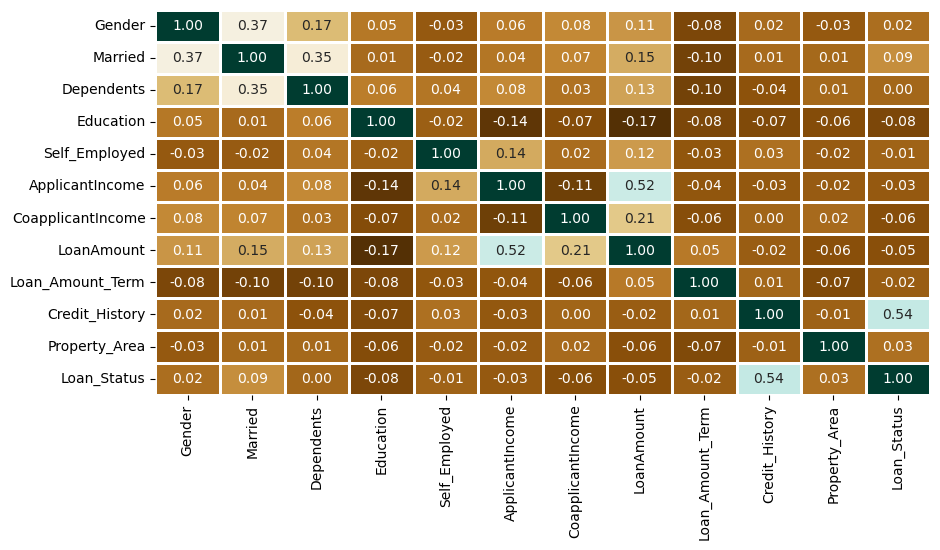

In [32]:
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(),cmap='BrBG',fmt='.2f',cbar=False,annot=True,linewidth=2)

In [26]:
for col in data.columns:
    data[col] = data[col].fillna(data[col].mean())
data.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [27]:
from sklearn.model_selection import train_test_split

x = data.drop(['Loan_Status'],axis=1)
y = data['Loan_Status']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)


In [28]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators = 7,
                             criterion = 'entropy',
                             random_state =7)
rfc.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=7, random_state=7)

In [30]:
from sklearn.metrics import accuracy_score
y_pred = rfc.predict(x_test)

accuracy = accuracy_score(y_pred, y_test)
accuracy*100

78.33333333333333